In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Neural Network

In [ ]:
class NeuralNetwork:
    def __init__(self,layers:list,activation:str,output_activation:str):
        self.layers = layers

        self.weights = []
        self.bias = []
        self.loss = []

        for index in range(len(self.layers)-1):
            self.weights.append(np.random.random((self.layers[index],self.layers[index+1])))
            self.bias.append(np.random.random((1,self.layers[index+1])))
        
        print(self.weights)
        print(self.bias)

    def forward_propogation(self):
        self.input = self.X
        
        for i in range(len(self.layers)-1):
            if(i==len(self.layers)-1):
                output = self.sigmoid(np.matmul(self.input,self.weights[i]) + self.bias[i])
            else:
                output = self.tanh(np.matmul(self.input,self.weights[i]) + self.bias[i])
            self.layer_output.append(output)
            self.input = output
        return output

    def sigmoid(self,x):
        return 1/(1+np.exp(-x))

    def tanh(self,x):
        return np.tanh(x)

    def predict(self,points,threshold = 0.5):
        return np.array([1 if x> threshold else 0 for x in points])

    def fit(self,X,y, n_iter = 1000, lr = 0.01):
        self.X = X
        self.y = y.reshape(-1,1) 
        for iter in range(n_iter):
            self.layer_output = [self.X]
            self.yp = self.forward_propogation().reshape(-1,1)
            loss = np.sum(-self.y*np.log(np.clip(self.yp,1e-8,1-1e-8)) - (1-self.y)*(np.log(np.clip(1-self.yp,1e-8,1-1e-8))))
            self.loss.append(loss/len(self.y))
            for l in range(len(self.layers)-1,0,-1):
                if(l==len(self.layers)-1):
                    delta = -(self.y - self.yp)/len(self.y)
                else:
                    # delta = (1-self.layer_output[l]@self.layer_output[l].T)*self.weights[l+1]@delta_l1.T
                    delta = delta_l1@self.weights[l].T*(1-self.layer_output[l]**2)

                delta_l1 = delta
                self.weights[l-1] = self.weights[l-1] - lr * self.layer_output[l-1].T@delta
                self.bias[l-1] = self.bias[l-1] - lr * delta
        return self.predict(self.yp)
        


(100, 2)
(100,)


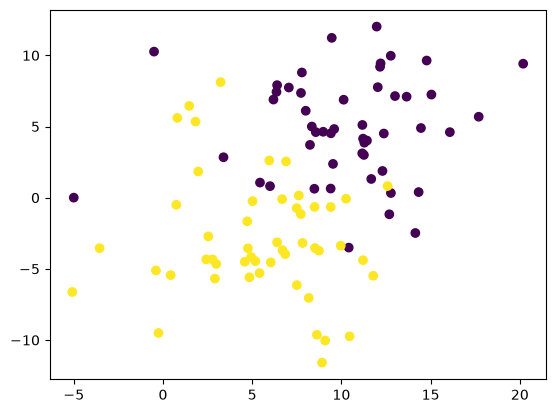

In [183]:
data = make_blobs(n_samples=100,n_features=2,centers=2,cluster_std=4)
X = data[0]
y = data[1]
print(X.shape)
print(y.shape)
plt.scatter(X[:,0],X[:,1],c=y)

In [184]:
nn = NeuralNetwork([X.shape[1],5,5,1],"tanh","sigmoid")
predict = nn.fit(X,y,n_iter=1000)

[array([[0.32634047, 0.56081267, 0.2485371 , 0.57749818, 0.81327931],
       [0.05998057, 0.21235928, 0.4814014 , 0.98889411, 0.26108551]]), array([[3.31905754e-01, 5.07687197e-01, 6.08587305e-01, 9.17345736e-01,
        2.71645815e-01],
       [4.38139865e-01, 3.43041634e-01, 6.58073283e-01, 4.80138517e-01,
        5.90804471e-02],
       [4.73563655e-04, 5.86050540e-01, 3.81432288e-01, 7.43041078e-02,
        1.55856920e-01],
       [4.85220379e-01, 8.11037552e-01, 7.54050143e-01, 4.34068020e-01,
        5.44571861e-01],
       [9.14253581e-01, 7.33216510e-01, 3.85013696e-01, 3.10056408e-01,
        6.96118996e-01]]), array([[0.27835899],
       [0.98372526],
       [0.34140514],
       [0.52334531],
       [0.10595708]])]
[array([[0.5416923 , 0.95696179, 0.92068889, 0.39264111, 0.87334543]]), array([[0.0304242 , 0.68502927, 0.65723541, 0.47025836, 0.48777778]]), array([[0.67466627]])]


IndexError: list index out of range

Text(0.5, 0.98, 'Accuracy: 0.48')

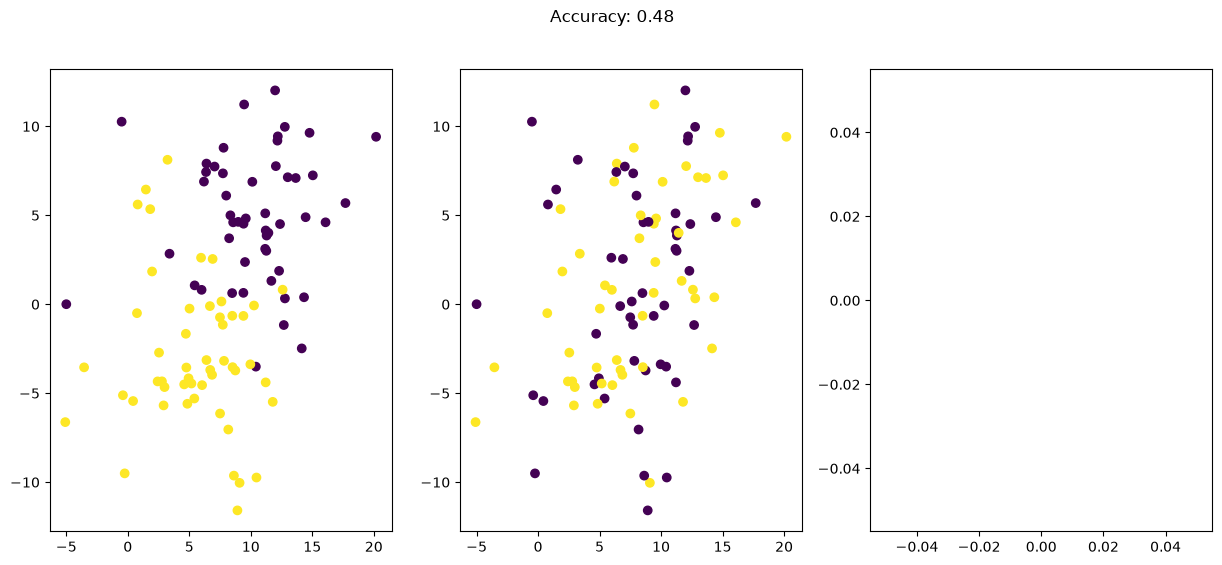

In [185]:
acc = np.sum(y == predict)/len(y)
fig,ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].scatter(X[:,0],X[:,1],c=y)
ax[1].scatter(X[:,0],X[:,1],c=predict)
ax[2].plot(nn.loss)
fig.suptitle(f"Accuracy: {acc}")